In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("/kaggle/input/datasets/himanshupoddar/zomato-bangalore-restaurants/zomato.csv")

df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [4]:
print(df.shape)
df.info()
df.isnull().sum()

(51717, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list       

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [5]:
df.drop_duplicates(inplace=True)

In [8]:
df = df[df['rate'].notna()]
df = df[df['rate'] != 'NEW']
df = df[df['rate'] != '-']

df['rate'] = df['rate'].str.split('/').str[0]
df['rate'] = df['rate'].astype(float)

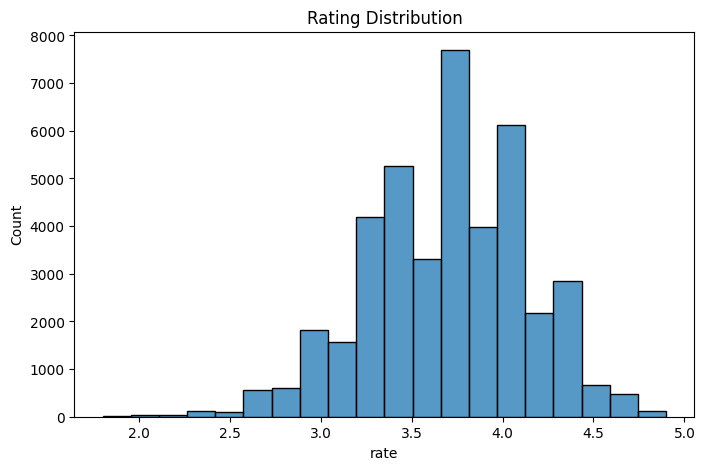

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['rate'], bins=20)
plt.title("Rating Distribution")
plt.show()

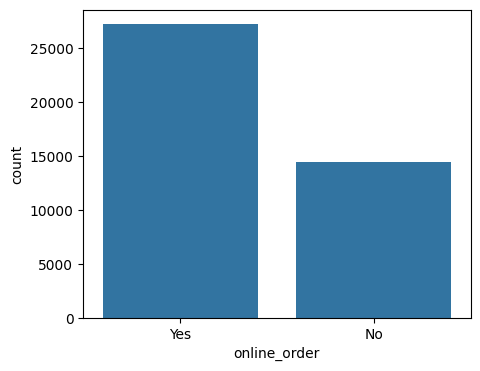

In [11]:
plt.figure(figsize=(5,4))
sns.countplot(x='online_order', data=df)
plt.show()

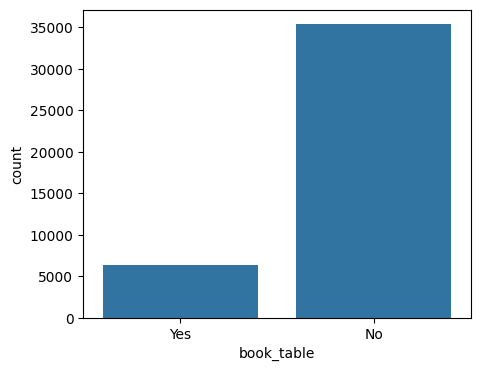

In [12]:
plt.figure(figsize=(5,4))
sns.countplot(x='book_table', data=df)
plt.show()

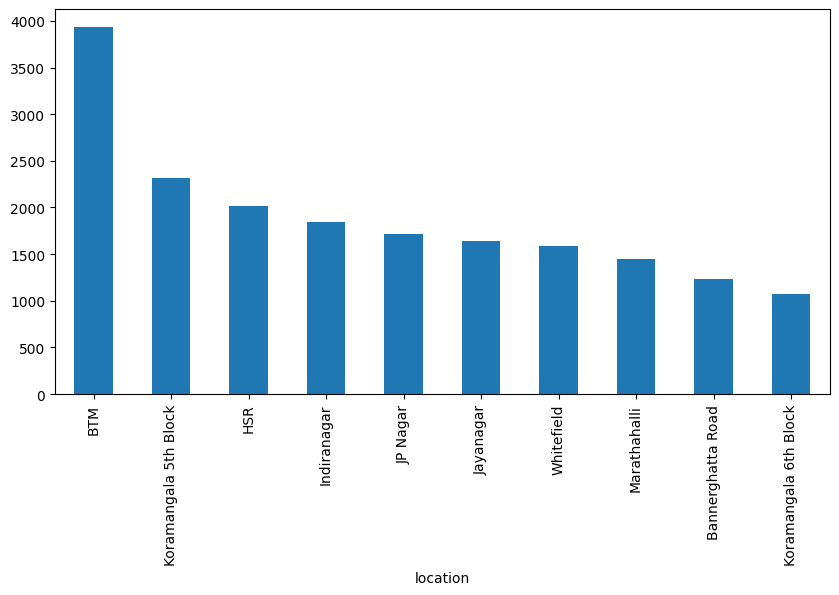

In [13]:
plt.figure(figsize=(10,5))
df['location'].value_counts().head(10).plot(kind='bar')
plt.show()

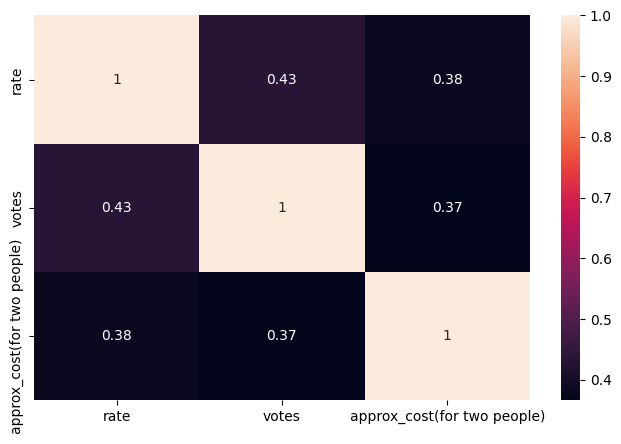

In [14]:
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

In [15]:
top_locations = df['location'].value_counts().head(15).index

df['location'] = df['location'].apply(
    lambda x: x if x in top_locations else 'Others'
)

top_cuisines = df['cuisines'].value_counts().head(20).index

df['cuisines'] = df['cuisines'].apply(
    lambda x: x if x in top_cuisines else 'Others'
)

In [16]:
X = df.drop('rate', axis=1)

y = df['rate']

In [17]:
categorical_cols = X.select_dtypes(include='object').columns

numerical_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['votes', 'approx_cost(for two people)'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['address', 'name', 'online_order', 'book_table', 'location',
       'rest_type', 'cuisines', 'listed_in(type)', 'listed_in(city)'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [23]:
dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

dt.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['votes', 'approx_cost(for two people)'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['address', 'name', 'online_order', 'book_table', 'location',
       'rest_type', 'cuisines', 'listed_in(type)', 'listed_in(city)'],
      dtype='object'))])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [30]:
def evaluate_model(model):

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    r2 = r2_score(y_test, pred)

    return mae, rmse, r2

In [31]:
results = []

models = {
    "Linear Regression": lr,
    "Decision Tree": dt
}

for name, model in models.items():

    mae, rmse, r2 = evaluate_model(model)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.032187,0.104089,0.943997
1,Decision Tree,0.033277,0.124329,0.920099


In [32]:
best_model = results_df.sort_values(
    by='R2 Score',
    ascending=False
)

print(best_model)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  0.032187  0.104089  0.943997
1      Decision Tree  0.033277  0.124329  0.920099


In [33]:
best = dt      # or lr depending on results

pred = best.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2 Score:", r2_score(y_test, pred))

MAE : 0.033277331093244024
RMSE: 0.1243294748349422
R2 Score: 0.9200993007920713
